In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv("../DATA/PROCESS/save_dataset3.csv")

In [4]:
df.drop(columns=["Unnamed: 0.1", "Unnamed: 0"], inplace=True)

## Random Test

In [ ]:
# # 1. 기본 세팅

# target_col = "target"

# drop_cols = [
#     target_col,
#     "datetime",
# ]

# drop_cols = [col for col in drop_cols if col in df.columns]

# X = df.drop(columns=drop_cols)
# y = df[target_col]

# print("X shape:", X.shape)
# print("y distribution:")
# print(y.value_counts(normalize=True))


# # 2. 컬럼 타입 분리


# categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
# numeric_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

# print("numeric cols:", len(numeric_cols))
# print("categorical cols:", len(categorical_cols))

# # 3. 전처리 파이프라인

# numeric_transformer = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="median")),
#     ("scaler", StandardScaler())
# ])

# categorical_transformer = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("onehot", OneHotEncoder(handle_unknown="ignore"))
# ])

# preprocessor = ColumnTransformer(
#     transformers=[
#         ("num", numeric_transformer, numeric_cols),
#         ("cat", categorical_transformer, categorical_cols),
#     ]
# )

# # 4. Train/Test split

# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

# print("train target distribution:")
# print(y_train.value_counts(normalize=True))

# print("test target distribution:")
# print(y_test.value_counts(normalize=True))

# # 5. 모델 학습

# model = Pipeline(steps=[
#     ("preprocess", preprocessor),
#     ("clf", RandomForestClassifier(
#         n_estimators=300,
#         random_state=42,
#         class_weight="balanced",
#         n_jobs=-1
#     ))
# ])

# model.fit(X_train, y_train)

# # 6. 예측 및 평가

# y_pred = model.predict(X_test)
# y_proba = model.predict_proba(X_test)[:, 1]

# print("\nClassification Report")
# print(classification_report(y_test, y_pred, digits=4))

# print("\nConfusion Matrix")
# print(confusion_matrix(y_test, y_pred))

# print("\nROC-AUC")
# print(roc_auc_score(y_test, y_proba))

X shape: (4033906, 97)
y distribution:
target
0    0.505813
1    0.494187
Name: proportion, dtype: float64
numeric cols: 95
categorical cols: 2


/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_74879/1362361736.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


train target distribution:
target
0    0.505813
1    0.494187
Name: proportion, dtype: float64
test target distribution:
target
0    0.505813
1    0.494187
Name: proportion, dtype: float64


KeyboardInterrupt: 

In [ ]:
# # 7. Feature Importance 확인

# rf = model.named_steps["clf"]

# feature_names = model.named_steps["preprocess"].get_feature_names_out()

# importance_df = pd.DataFrame({
#     "feature": feature_names,
#     "importance": rf.feature_importances_
# }).sort_values("importance", ascending=False)

# importance_df.head(30)

,feature,importance
3,num__hour,0.127907
7,num__hour_cos,0.078663
6,num__hour_sin,0.063019
42,num__rest_cnt_500m,0.054801
43,num__rest_cnt_1000m,0.029487
41,num__rest_cnt_300m,0.029143
85,num__subway_weighted_access_k5,0.027568
86,num__subway_mean_dist_k5_m,0.022304
12,num__gu_walk_area,0.019071
53,num__tour_food_mean_dist_k20_m,0.017638


## Time Test

In [ ]:
# df = df.sort_values("datetime")

# split_idx = int(len(df) * 0.8)

# X_train = X.iloc[:split_idx]
# X_test = X.iloc[split_idx:]

# y_train = y.iloc[:split_idx]
# y_test = y.iloc[split_idx:]

In [ ]:
# print("train target distribution:")
# print(y_train.value_counts(normalize=True))

# print("test target distribution:")
# print(y_test.value_counts(normalize=True))

# # 5. 모델 학습

# model = Pipeline(steps=[
#     ("preprocess", preprocessor),
#     ("clf", RandomForestClassifier(
#         n_estimators=300,
#         random_state=42,
#         class_weight="balanced",
#         n_jobs=-1
#     ))
# ])

# model.fit(X_train, y_train)

# # 6. 예측 및 평가

# y_pred = model.predict(X_test)
# y_proba = model.predict_proba(X_test)[:, 1]

# print("\nClassification Report")
# print(classification_report(y_test, y_pred, digits=4))

# print("\nConfusion Matrix")
# print(confusion_matrix(y_test, y_pred))

# print("\nROC-AUC")
# print(roc_auc_score(y_test, y_proba))

train target distribution:
target
0    0.578189
1    0.421811
Name: proportion, dtype: float64
test target distribution:
target
1    0.58939
0    0.41061
Name: proportion, dtype: float64

Classification Report
              precision    recall  f1-score   support

           0     0.3943    0.7289    0.5117     30365
           1     0.5378    0.2198    0.3120     43586

    accuracy                         0.4288     73951
   macro avg     0.4661    0.4744    0.4119     73951
weighted avg     0.4789    0.4288    0.3940     73951


Confusion Matrix
[[22134  8231]
 [34007  9579]]

ROC-AUC
0.6599856709035162


In [ ]:
# # 7. Feature Importance 확인

# rf = model.named_steps["clf"]

# feature_names = model.named_steps["preprocess"].get_feature_names_out()

# importance_df = pd.DataFrame({
#     "feature": feature_names,
#     "importance": rf.feature_importances_
# }).sort_values("importance", ascending=False)

# importance_df.head(30)

,feature,importance
3,num__hour,0.106530
7,num__hour_cos,0.061186
6,num__hour_sin,0.053349
42,num__rest_cnt_500m,0.050201
43,num__rest_cnt_1000m,0.038357
53,num__tour_food_mean_dist_k20_m,0.036078
85,num__subway_weighted_access_k5,0.025511
62,num__shop_mean_dist_k20_m,0.023320
41,num__rest_cnt_300m,0.022890
86,num__subway_mean_dist_k5_m,0.022373


In [ ]:
# importance_df.to_csv("../DATA/PROCESS/feature_importance.csv")

In [7]:
df.columns

Index(['datetime', '자치구코드', '위도', '경도', 'hour', 'weekday', 'month', 'hour_sin',
       'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos',
       'gu_walk_area', 'target', 'concert_total', 'concert_public',
       'concert_private', 'concert_large', 'concert_mid', 'concert_small',
       'heritage_total', 'designated_total', 'national_treasure', 'treasure',
       'historic_site', 'scenic_site', 'historic_and_scenic_site',
       'natural_monument', 'folk_cultural_property',
       'intangible_cultural_property', 'city_designated_total',
       'tangible_cultural_property', 'city_monument',
       'city_folk_cultural_property', 'city_intangible_cultural_property',
       'cultural_property_material', 'national_registered_cultural_property',
       'city_registered_cultural_property', 'movie_theater_cnt',
       'movie_screen_cnt', 'movie_seat_cnt', 'rest_cnt_100m', 'rest_cnt_300m',
       'rest_cnt_500m', 'rest_cnt_1000m', 'nearest_rest_dist_m',
       'rest_weighted_de

In [8]:
# =========================================================
# Interaction Feature Logistic 실험
# - 샘플링 없음
# - 핵심 컬럼 기반 상호작용 피처 생성
# - 단일 피처 대비 상호작용 피처의 성능 개선 검증
# =========================================================

import gc
import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score


# =========================================================
# 1. 기본 설정
# =========================================================

target_col = "target"

drop_cols = [
    target_col,
    "datetime"
]

drop_cols = [c for c in drop_cols if c in df.columns]

print("Original df shape:", df.shape)
print("\nTarget distribution:")
print(df[target_col].value_counts(normalize=True))


# =========================================================
# 2. 핵심 단일 피처 선정
# =========================================================
# 너무 많은 컬럼을 쓰지 않고,
# 시간 / 보행환경 / 음식 / 상권 / 교통 / 문화 기능을 대표하는 컬럼만 사용

core_features = [
    # 시간 주기성
    "hour_sin", "hour_cos",
    "weekday_sin", "weekday_cos",
    "month_sin", "month_cos",

    # 보행 환경
    "gu_walk_area",

    # 문화 기능
    "concert_total",
    "heritage_total",
    "movie_theater_cnt",
    "movie_screen_cnt",
    "movie_seat_cnt",

    # 음식 접근성
    "rest_cnt_300m",
    "rest_cnt_500m",
    "rest_cnt_1000m",
    "nearest_rest_dist_m",
    "rest_weighted_density_k20",

    # 관광 음식
    "tour_food_cnt_300m",
    "tour_food_cnt_500m",
    "tour_food_ratio_300m",
    "tour_food_ratio_500m",

    # 상권 기능
    "shop_cnt_300m_x",
    "shop_cnt_500m_x",
    "shop_cnt_1000m_x",
    "shop_type_cnt_500m_x",
    "shop_type_entropy_500m",
    "shop_store_type_entropy_500m",

    # 버스 접근성
    "bus_stop_cnt_100m",
    "bus_stop_cnt_300m",
    "bus_stop_cnt_500m",

    # 지하철 접근성
    "subway_cnt_300m_x",
    "subway_cnt_500m_x",
    "subway_cnt_1000m_x",
    "nearest_subway_dist_m_x",
    "subway_weighted_access_k5_x",
    "subway_line_cnt_1000m",
    "subway_line_entropy_1000m",
]

core_features = [c for c in core_features if c in df.columns]

print("\nSelected core features:", len(core_features))
for c in core_features:
    print("-", c)


# =========================================================
# 3. 분석용 X, y 생성
# =========================================================

X_main = df[core_features].copy()
y = df[target_col].astype(int).copy()

# 메모리 절약을 위해 float32 변환
for col in tqdm(X_main.columns, desc="Downcasting core features"):
    X_main[col] = pd.to_numeric(X_main[col], errors="coerce").astype("float32")

print("\nX_main shape:", X_main.shape)


# =========================================================
# 4. 상호작용 피처 생성
# =========================================================
# 무작위 조합이 아니라 도메인 해석 가능한 조합만 생성
# 예:
# 시간 × 교통
# 시간 × 소비/상권
# 교통 × 음식
# 교통 × 문화
# 상권 다양성 × 음식 밀도
# 보행면적 × 밀집 기능

def safe_divide(a, b, eps=1e-6):
    return a / (np.abs(b) + eps)


interaction_specs = [
    # -----------------------------------------------------
    # 시간 × 교통 접근성
    # -----------------------------------------------------
    ("hour_sin", "subway_cnt_1000m_x", "mul"),
    ("hour_cos", "subway_cnt_1000m_x", "mul"),
    ("weekday_sin", "subway_cnt_1000m_x", "mul"),
    ("weekday_cos", "subway_cnt_1000m_x", "mul"),
    ("hour_sin", "bus_stop_cnt_500m", "mul"),
    ("hour_cos", "bus_stop_cnt_500m", "mul"),

    # -----------------------------------------------------
    # 시간 × 음식/상권 기능
    # -----------------------------------------------------
    ("hour_sin", "rest_cnt_500m", "mul"),
    ("hour_cos", "rest_cnt_500m", "mul"),
    ("weekday_sin", "rest_cnt_500m", "mul"),
    ("weekday_cos", "rest_cnt_500m", "mul"),
    ("hour_sin", "shop_cnt_500m_x", "mul"),
    ("hour_cos", "shop_cnt_500m_x", "mul"),

    # -----------------------------------------------------
    # 교통 × 음식 접근성
    # -----------------------------------------------------
    ("subway_cnt_1000m_x", "rest_cnt_500m", "mul"),
    ("subway_cnt_500m_x", "rest_cnt_300m", "mul"),
    ("bus_stop_cnt_500m", "rest_cnt_500m", "mul"),
    ("subway_weighted_access_k5_x", "rest_weighted_density_k20", "mul"),

    # -----------------------------------------------------
    # 교통 × 상권 기능
    # -----------------------------------------------------
    ("subway_cnt_1000m_x", "shop_cnt_500m_x", "mul"),
    ("subway_cnt_500m_x", "shop_type_cnt_500m_x", "mul"),
    ("bus_stop_cnt_500m", "shop_cnt_500m_x", "mul"),
    ("subway_weighted_access_k5_x", "shop_type_entropy_500m", "mul"),

    # -----------------------------------------------------
    # 문화 × 교통
    # -----------------------------------------------------
    ("concert_total", "subway_cnt_1000m_x", "mul"),
    ("heritage_total", "subway_cnt_1000m_x", "mul"),
    ("movie_theater_cnt", "subway_cnt_1000m_x", "mul"),

    # -----------------------------------------------------
    # 음식 × 상권 다양성
    # -----------------------------------------------------
    ("rest_cnt_500m", "shop_type_entropy_500m", "mul"),
    ("tour_food_ratio_500m", "shop_type_entropy_500m", "mul"),
    ("rest_weighted_density_k20", "shop_store_type_entropy_500m", "mul"),

    # -----------------------------------------------------
    # 보행면적 대비 기능 밀도
    # -----------------------------------------------------
    ("rest_cnt_500m", "gu_walk_area", "ratio"),
    ("shop_cnt_500m_x", "gu_walk_area", "ratio"),
    ("subway_cnt_1000m_x", "gu_walk_area", "ratio"),
    ("concert_total", "gu_walk_area", "ratio"),

    # -----------------------------------------------------
    # 거리 기반 접근성 보정
    # -----------------------------------------------------
    ("rest_cnt_500m", "nearest_rest_dist_m", "ratio"),
    ("subway_cnt_1000m_x", "nearest_subway_dist_m_x", "ratio"),
    ("shop_cnt_500m_x", "nearest_subway_dist_m_x", "ratio"),
]


def create_interaction_features(X, specs):
    X_inter = X.copy()

    created = []

    for col1, col2, op in tqdm(specs, desc="Creating interaction features"):
        if col1 not in X_inter.columns or col2 not in X_inter.columns:
            continue

        if op == "mul":
            new_col = f"{col1}__x__{col2}"
            X_inter[new_col] = (
                X_inter[col1].astype("float32") * X_inter[col2].astype("float32")
            ).astype("float32")

        elif op == "ratio":
            new_col = f"{col1}__div__{col2}"
            X_inter[new_col] = safe_divide(
                X_inter[col1].astype("float32"),
                X_inter[col2].astype("float32")
            ).astype("float32")

        else:
            continue

        created.append(new_col)

    return X_inter, created


X_interaction, interaction_cols = create_interaction_features(
    X_main,
    interaction_specs
)

print("\nCreated interaction features:", len(interaction_cols))
for c in interaction_cols:
    print("-", c)

print("\nX_main shape:", X_main.shape)
print("X_interaction shape:", X_interaction.shape)


# =========================================================
# 5. 평가 함수
# =========================================================

def calculate_lift(y_true, y_proba, top_ratio):
    temp = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_proba": np.asarray(y_proba)
    })

    temp = temp.sort_values("y_proba", ascending=False)

    top_n = max(1, int(len(temp) * top_ratio))

    base_rate = temp["y_true"].mean()
    top_rate = temp.iloc[:top_n]["y_true"].mean()

    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return lift, top_rate, base_rate


def evaluate_prediction(model_name, y_test, y_proba):
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    lift_5, top_rate_5, base_rate = calculate_lift(y_test, y_proba, 0.05)
    lift_10, top_rate_10, _ = calculate_lift(y_test, y_proba, 0.10)
    lift_20, top_rate_20, _ = calculate_lift(y_test, y_proba, 0.20)

    return {
        "model": model_name,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "Lift@5%": lift_5,
        "Lift@10%": lift_10,
        "Lift@20%": lift_20,
        "Top5%_positive_rate": top_rate_5,
        "Top10%_positive_rate": top_rate_10,
        "Top20%_positive_rate": top_rate_20,
        "Base_positive_rate": base_rate,
    }


# =========================================================
# 6. Logistic 학습 함수
# =========================================================

def train_logistic_and_evaluate(X, y, model_name):
    print(f"\n===== {model_name} =====")
    print("Input shape:", X.shape)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    print("Train shape:", X_train.shape)
    print("Test shape:", X_test.shape)

    pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(
            solver="saga",
            penalty="l2",
            C=1.0,
            class_weight="balanced",
            max_iter=300,
            n_jobs=-1,
            random_state=42,
            verbose=0
        ))
    ])

    for _ in tqdm(range(1), desc=f"Training {model_name}"):
        pipe.fit(X_train, y_train)

    for _ in tqdm(range(1), desc=f"Predicting {model_name}"):
        y_proba = pipe.predict_proba(X_test)[:, 1]

    result = evaluate_prediction(model_name, y_test, y_proba)

    del X_train, X_test, y_train, y_test
    gc.collect()

    return result, pipe


# =========================================================
# 7. 실험 1: 핵심 단일 피처 전체 모델
# =========================================================

results = []

result_main, pipe_main = train_logistic_and_evaluate(
    X_main,
    y,
    model_name="Logistic_main_features_only"
)
results.append(result_main)


# =========================================================
# 8. 실험 2: 핵심 단일 피처 + 상호작용 피처 모델
# =========================================================

result_inter, pipe_inter = train_logistic_and_evaluate(
    X_interaction,
    y,
    model_name="Logistic_main_plus_interaction"
)
results.append(result_inter)


# =========================================================
# 9. 실험 3: Best single feature 모델들과 비교
# =========================================================
# 각 단일 피처 하나만 사용했을 때의 성능을 계산
# interaction 모델이 단일 피처 모델보다 우수함을 보여주기 위함

single_feature_results = []

for col in tqdm(core_features, desc="Training single-feature logistic models"):
    X_single = X_main[[col]].copy()

    try:
        result_single, _ = train_logistic_and_evaluate(
            X_single,
            y,
            model_name=f"Single__{col}"
        )
        single_feature_results.append(result_single)

    except Exception as e:
        print(f"[SKIP] {col}: {e}")

    del X_single
    gc.collect()

single_feature_df = pd.DataFrame(single_feature_results)

single_feature_df = single_feature_df.sort_values(
    by="Lift@10%",
    ascending=False
).reset_index(drop=True)

print("\n===== Top 10 Single Feature Models by Lift@10% =====")
print(single_feature_df.head(10))


# =========================================================
# 10. 결과 비교표
# =========================================================

comparison_df = pd.DataFrame(results)

metric_cols = [
    "ROC_AUC",
    "PR_AUC",
    "Lift@5%",
    "Lift@10%",
    "Lift@20%",
    "Top5%_positive_rate",
    "Top10%_positive_rate",
    "Top20%_positive_rate",
    "Base_positive_rate"
]

comparison_df[metric_cols] = comparison_df[metric_cols].round(4)
single_feature_df[metric_cols] = single_feature_df[metric_cols].round(4)

print("\n===== Main Comparison =====")
print(comparison_df)

print("\n===== Best Single Feature Comparison =====")
print(single_feature_df.head(10))


# =========================================================
# 11. 개선폭 계산
# =========================================================

main_only = comparison_df[
    comparison_df["model"] == "Logistic_main_features_only"
].iloc[0]

main_plus_inter = comparison_df[
    comparison_df["model"] == "Logistic_main_plus_interaction"
].iloc[0]

best_single = single_feature_df.iloc[0]

improvement_df = pd.DataFrame([
    {
        "comparison": "main_plus_interaction - main_features_only",
        "ROC_AUC_diff": main_plus_inter["ROC_AUC"] - main_only["ROC_AUC"],
        "PR_AUC_diff": main_plus_inter["PR_AUC"] - main_only["PR_AUC"],
        "Lift@5%_diff": main_plus_inter["Lift@5%"] - main_only["Lift@5%"],
        "Lift@10%_diff": main_plus_inter["Lift@10%"] - main_only["Lift@10%"],
        "Lift@20%_diff": main_plus_inter["Lift@20%"] - main_only["Lift@20%"],
    },
    {
        "comparison": "main_plus_interaction - best_single_feature",
        "ROC_AUC_diff": main_plus_inter["ROC_AUC"] - best_single["ROC_AUC"],
        "PR_AUC_diff": main_plus_inter["PR_AUC"] - best_single["PR_AUC"],
        "Lift@5%_diff": main_plus_inter["Lift@5%"] - best_single["Lift@5%"],
        "Lift@10%_diff": main_plus_inter["Lift@10%"] - best_single["Lift@10%"],
        "Lift@20%_diff": main_plus_inter["Lift@20%"] - best_single["Lift@20%"],
    }
])

improvement_df = improvement_df.round(4)

print("\n===== Improvement Summary =====")
print(improvement_df)


# =========================================================
# 12. Logistic 계수 기반 상호작용 피처 영향 확인
# =========================================================

feature_names = X_interaction.columns.tolist()

coef = pipe_inter.named_steps["logit"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "abs_coef": np.abs(coef)
})

coef_df["feature_type"] = np.where(
    coef_df["feature"].isin(interaction_cols),
    "interaction",
    "main"
)

coef_df = coef_df.sort_values(
    by="abs_coef",
    ascending=False
).reset_index(drop=True)

print("\n===== Top 30 Logistic Coefficients =====")
print(coef_df.head(30))

print("\n===== Top Interaction Coefficients =====")
print(coef_df[coef_df["feature_type"] == "interaction"].head(20))


# =========================================================
# 13. 저장
# =========================================================

comparison_df.to_csv(
    "logistic_main_vs_interaction_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

single_feature_df.to_csv(
    "logistic_single_feature_results.csv",
    index=False,
    encoding="utf-8-sig"
)

improvement_df.to_csv(
    "logistic_interaction_improvement_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

coef_df.to_csv(
    "logistic_interaction_coefficients.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n저장 완료:")
print("- logistic_main_vs_interaction_comparison.csv")
print("- logistic_single_feature_results.csv")
print("- logistic_interaction_improvement_summary.csv")
print("- logistic_interaction_coefficients.csv")

/Users/carolyn/Desktop/study/SEOULDATA/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Original df shape: (4033906, 99)

Target distribution:
target
0    0.505813
1    0.494187
Name: proportion, dtype: float64

Selected core features: 37
- hour_sin
- hour_cos
- weekday_sin
- weekday_cos
- month_sin
- month_cos
- gu_walk_area
- concert_total
- heritage_total
- movie_theater_cnt
- movie_screen_cnt
- movie_seat_cnt
- rest_cnt_300m
- rest_cnt_500m
- rest_cnt_1000m
- nearest_rest_dist_m
- rest_weighted_density_k20
- tour_food_cnt_300m
- tour_food_cnt_500m
- tour_food_ratio_300m
- tour_food_ratio_500m
- shop_cnt_300m_x
- shop_cnt_500m_x
- shop_cnt_1000m_x
- shop_type_cnt_500m_x
- shop_type_entropy_500m
- shop_store_type_entropy_500m
- bus_stop_cnt_100m
- bus_stop_cnt_300m
- bus_stop_cnt_500m
- subway_cnt_300m_x
- subway_cnt_500m_x
- subway_cnt_1000m_x
- nearest_subway_dist_m_x
- subway_weighted_access_k5_x
- subway_line_cnt_1000m
- subway_line_entropy_1000m


Downcasting core features: 100%|██████████| 37/37 [00:01<00:00, 36.43it/s]



X_main shape: (4033906, 37)


Creating interaction features: 100%|██████████| 33/33 [00:00<00:00, 127.79it/s]


...


===== Single__subway_line_cnt_1000m =====
Input shape: (4033906, 1)
Train shape: (3227124, 1)
Test shape: (806782, 1)


/Users/carolyn/Desktop/study/SEOULDATA/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/carolyn/Desktop/study/SEOULDATA/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
Training single-feature logistic models:  97%|█████████▋| 36/37 [04:52<00:07,  7.17s/it]


===== Single__subway_line_entropy_1000m =====
Input shape: (4033906, 1)
Train shape: (3227124, 1)
Test shape: (806782, 1)


/Users/carolyn/Desktop/study/SEOULDATA/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/carolyn/Desktop/study/SEOULDATA/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
Training single-feature logistic models: 100%|██████████| 37/37 [05:00<00:00,  8.13s/it]


===== Top 10 Single Feature Models by Lift@10% =====
                               model   ROC_AUC    PR_AUC   Lift@5%  Lift@10%  \
0             Single__rest_cnt_1000m  0.647775  0.673042  1.547680  1.688588   
1              Single__rest_cnt_500m  0.645279  0.664731  1.747529  1.673037   
2  Single__subway_line_entropy_1000m  0.591516  0.591602  1.591272  1.607148   
3         Single__subway_cnt_1000m_x  0.614003  0.615621  1.771858  1.581866   
4            Single__shop_cnt_500m_x  0.571239  0.582489  1.691848  1.575320   
5       Single__shop_type_cnt_500m_x  0.586966  0.582057  1.682568  1.564058   
6           Single__shop_cnt_1000m_x  0.570709  0.589908  1.757562  1.539353   
7      Single__subway_line_cnt_1000m  0.602338  0.581361  1.457788  1.488362   
8     Single__shop_type_entropy_500m  0.586283  0.570515  1.207876  1.484500   
9            Single__shop_cnt_300m_x  0.566278  0.568373  1.678856  1.462027   

   Lift@20%  Top5%_positive_rate  Top10%_positive_rate  Top20%_po

In [10]:
# =========================================================
# 12. Logistic 계수 + OR 기반 상호작용 피처 영향 확인
# =========================================================

feature_names = X_interaction.columns.tolist()

coef = pipe_inter.named_steps["logit"].coef_[0]

# Odds Ratio
OR = np.exp(coef)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "OR": OR,
    "abs_coef": np.abs(coef),
    "abs_log_OR": np.abs(np.log(OR))
})

coef_df["feature_type"] = np.where(
    coef_df["feature"].isin(interaction_cols),
    "interaction",
    "main"
)

# OR 기준 정렬
coef_df = coef_df.sort_values(
    by="OR",
    ascending=False
).reset_index(drop=True)


print("\n===== Top Positive OR =====")
print(
    coef_df[
        ["feature", "feature_type", "coef", "OR"]
    ].head(30)
)

print("\n===== Top Negative OR =====")
print(
    coef_df.sort_values(
        by="OR",
        ascending=True
    )[
        ["feature", "feature_type", "coef", "OR"]
    ].head(30)
)

print("\n===== Top Interaction OR =====")
print(
    coef_df[
        coef_df["feature_type"] == "interaction"
    ].head(20)
)


# 저장
coef_df.to_csv(
    "logistic_interaction_OR.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nlogistic_interaction_OR.csv 저장 완료")


===== Top Positive OR =====
                                              feature feature_type       coef  \
0                    concert_total__div__gu_walk_area  interaction  11.929068   
1              subway_cnt_1000m_x__x__shop_cnt_500m_x  interaction   7.179470   
2                 subway_cnt_500m_x__x__rest_cnt_300m  interaction   6.230456   
3                                  subway_cnt_1000m_x         main   4.331227   
4                                       rest_cnt_500m         main   4.295382   
5       shop_cnt_500m_x__div__nearest_subway_dist_m_x  interaction   3.242371   
6                                     shop_cnt_300m_x         main   2.737118   
7                                     shop_cnt_500m_x         main   2.456383   
8            rest_cnt_500m__x__shop_type_entropy_500m  interaction   2.245445   
9                                shop_type_cnt_500m_x         main   2.201995   
10              subway_cnt_1000m_x__div__gu_walk_area  interaction   2.108942   

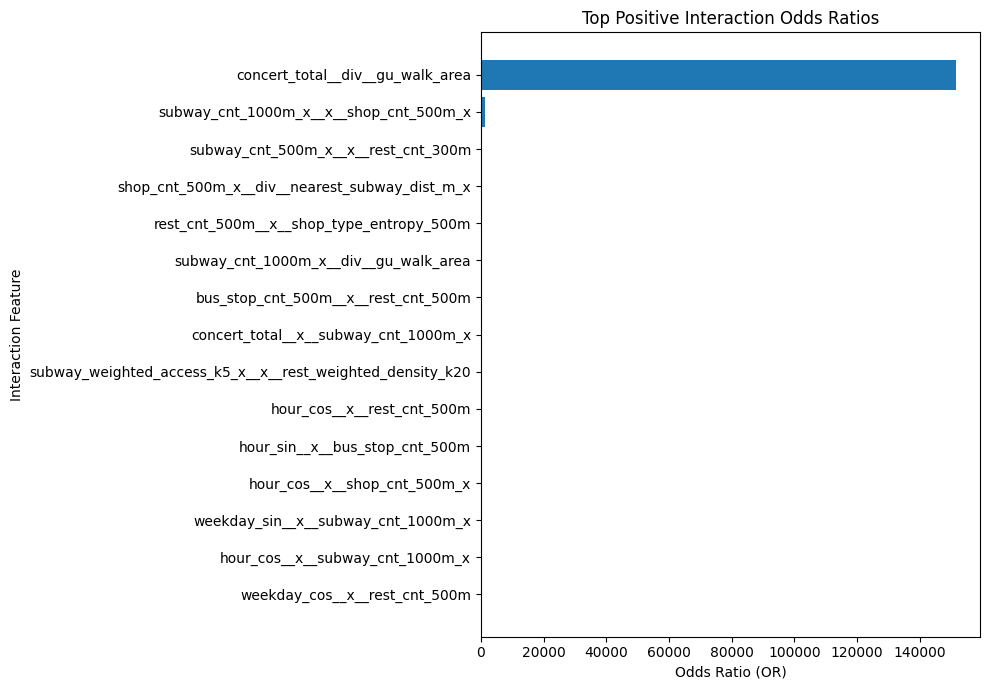

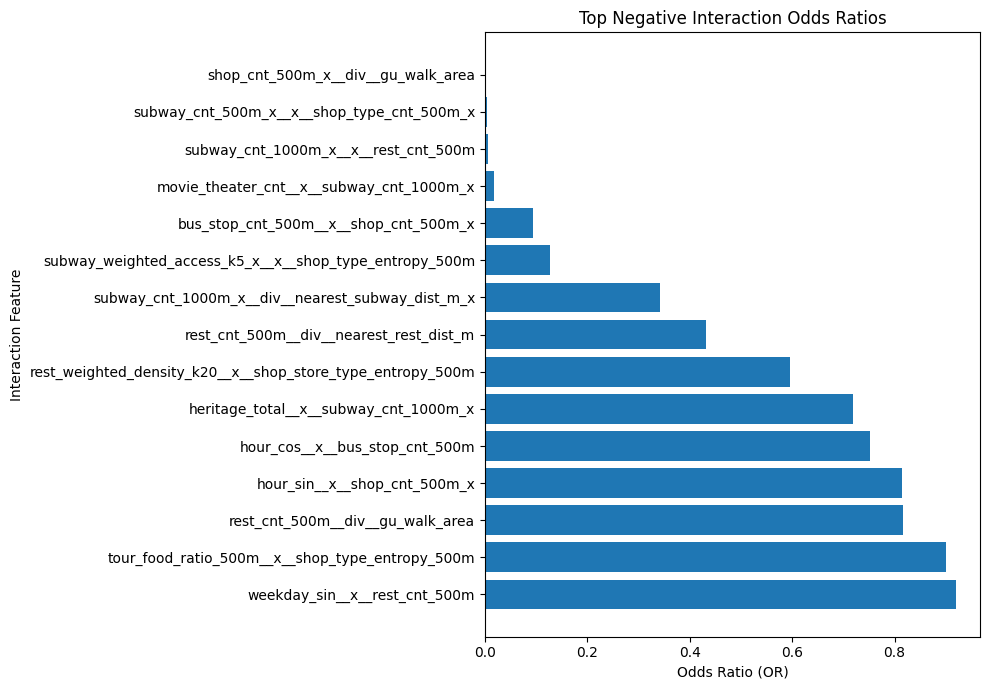

In [11]:
import matplotlib.pyplot as plt
import numpy as np


# =========================================================
# 1. Interaction feature만 추출
# =========================================================

interaction_or = coef_df[
    coef_df["feature_type"] == "interaction"
].copy()


# =========================================================
# 2. Positive / Negative OR 분리
# =========================================================

top_positive = interaction_or.sort_values(
    by="OR",
    ascending=False
).head(15)

top_negative = interaction_or.sort_values(
    by="OR",
    ascending=True
).head(15)


# =========================================================
# 3. Positive OR 시각화
# =========================================================

plt.figure(figsize=(10, 7))

plt.barh(
    top_positive["feature"][::-1],
    top_positive["OR"][::-1]
)

plt.xlabel("Odds Ratio (OR)")
plt.ylabel("Interaction Feature")
plt.title("Top Positive Interaction Odds Ratios")

plt.tight_layout()
plt.show()


# =========================================================
# 4. Negative OR 시각화
# =========================================================

plt.figure(figsize=(10, 7))

plt.barh(
    top_negative["feature"][::-1],
    top_negative["OR"][::-1]
)

plt.xlabel("Odds Ratio (OR)")
plt.ylabel("Interaction Feature")
plt.title("Top Negative Interaction Odds Ratios")

plt.tight_layout()
plt.show()

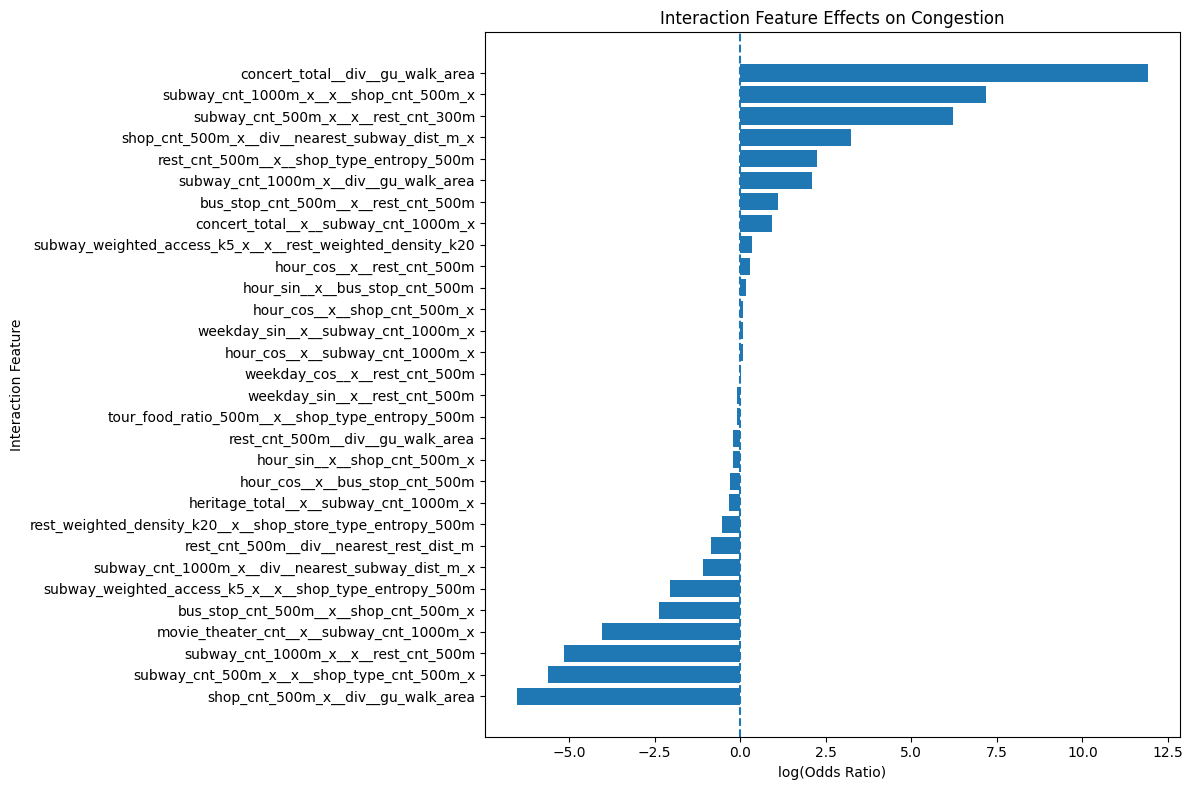

In [12]:
# =========================================================
# log(OR) 기반 시각화
# =========================================================

interaction_or["log_OR"] = np.log(interaction_or["OR"])

top_effect = interaction_or.sort_values(
    by="log_OR",
    ascending=False
).head(15)

top_negative = interaction_or.sort_values(
    by="log_OR",
    ascending=True
).head(15)

plot_df = pd.concat([
    top_effect,
    top_negative
])

plot_df = plot_df.sort_values("log_OR")


plt.figure(figsize=(12, 8))

plt.barh(
    plot_df["feature"],
    plot_df["log_OR"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("log(Odds Ratio)")
plt.ylabel("Interaction Feature")
plt.title("Interaction Feature Effects on Congestion")

plt.tight_layout()
plt.show()

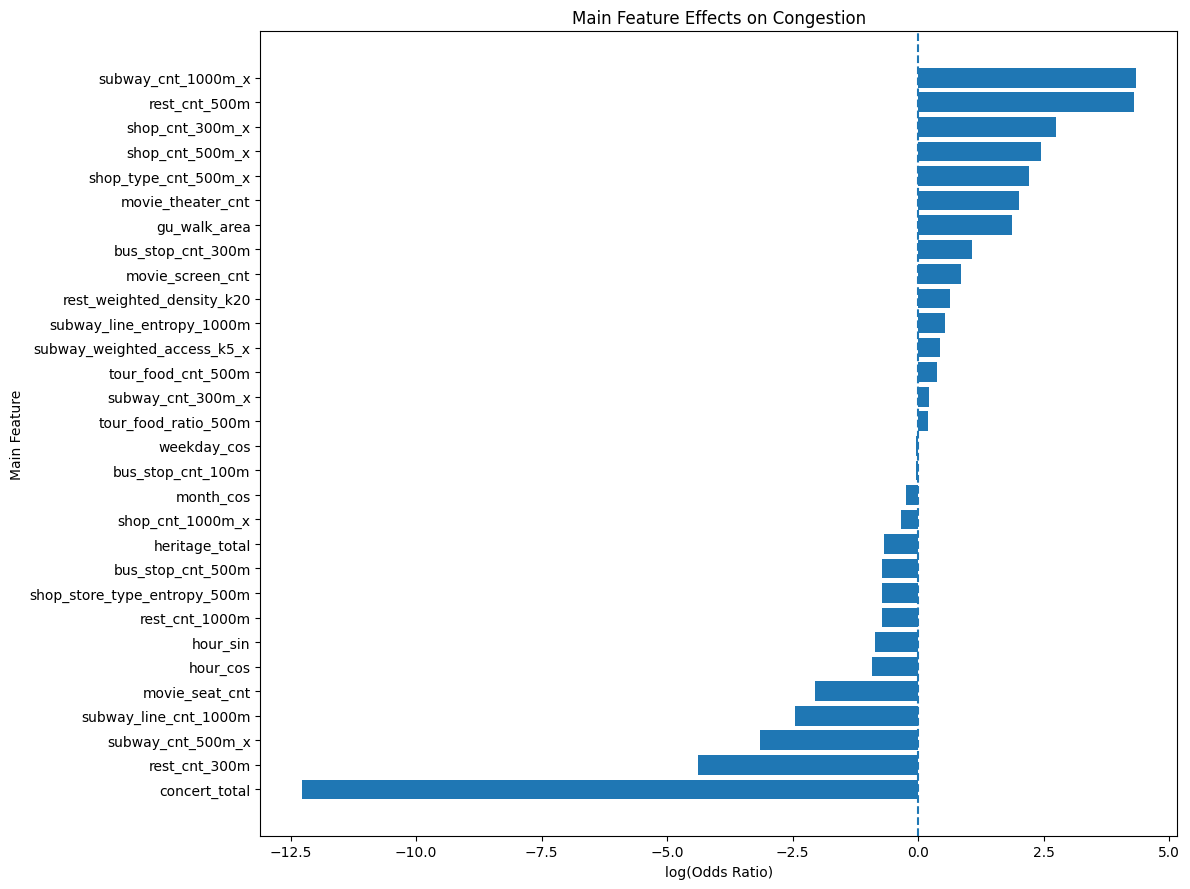

In [13]:
# =========================================================
# 일반 피처(main feature) 계수 / OR 시각화
# =========================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# 1. 일반 피처만 추출
main_coef = coef_df[
    coef_df["feature_type"] == "main"
].copy()

# 혹시 OR, log_OR 컬럼이 없다면 생성
if "OR" not in main_coef.columns:
    main_coef["OR"] = np.exp(main_coef["coef"])

main_coef["log_OR"] = np.log(main_coef["OR"])


# =========================================================
# 2. log(OR) 기준 상위 positive / negative 피처 추출
# =========================================================

top_positive_main = main_coef.sort_values(
    by="log_OR",
    ascending=False
).head(15)

top_negative_main = main_coef.sort_values(
    by="log_OR",
    ascending=True
).head(15)

plot_main = pd.concat([
    top_negative_main,
    top_positive_main
])

plot_main = plot_main.sort_values("log_OR")


# =========================================================
# 3. 일반 피처 log(OR) 시각화
# =========================================================

plt.figure(figsize=(12, 9))

plt.barh(
    plot_main["feature"],
    plot_main["log_OR"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("log(Odds Ratio)")
plt.ylabel("Main Feature")
plt.title("Main Feature Effects on Congestion")

plt.tight_layout()
plt.show()

사용 피처 수: 14
['subway_line_entropy_1000m', 'subway_mean_dist_k5_m_x', 'rest_cnt_500m', 'shop_weighted_density_k20_x', 'movie_theater_cnt', 'shop_type_entropy_500m', 'gu_walk_area', 'concert_total', 'tour_food_weighted_density_k20', 'nearest_rest_dist_m', 'bus_stop_cnt_300m', 'month', 'hour', 'weekday']
X shape: (4033906, 14)
Target distribution:
target
0    0.505813
1    0.494187
Name: proportion, dtype: float64


/Users/carolyn/Desktop/study/SEOULDATA/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



ROC-AUC: 0.7247125321988346
PR-AUC: 0.729289307434816

===== OR 결과 =====
                           feature      coef        OR    log_OR  abs_coef
0        subway_line_entropy_1000m -0.098882  0.905849 -0.098882  0.098882
1          subway_mean_dist_k5_m_x -0.062092  0.939796 -0.062092  0.062092
2                            month -0.045949  0.955091 -0.045949  0.045949
3                          weekday -0.011803  0.988266 -0.011803  0.011803
4           shop_type_entropy_500m  0.007304  1.007331  0.007304  0.007304
5                movie_theater_cnt  0.027464  1.027844  0.027464  0.027464
6                     gu_walk_area  0.094741  1.099374  0.094741  0.094741
7                    concert_total  0.176579  1.193129  0.176579  0.176579
8              nearest_rest_dist_m  0.189416  1.208543  0.189416  0.189416
9                bus_stop_cnt_300m  0.225420  1.252848  0.225420  0.225420
10  tour_food_weighted_density_k20  0.254148  1.289362  0.254148  0.254148
11     shop_weighted_densi

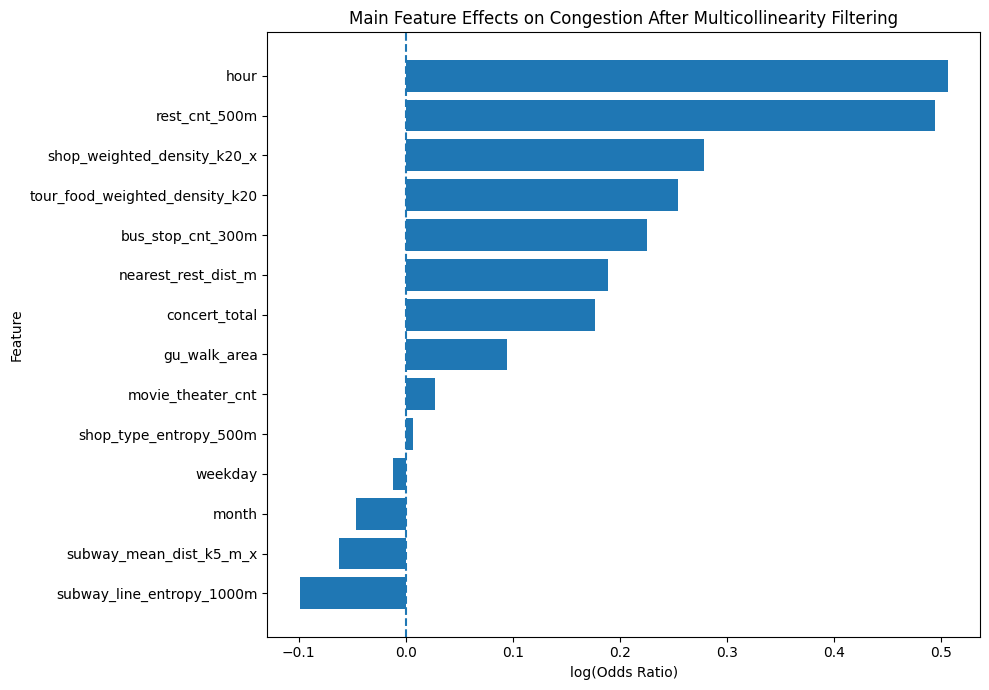


저장 완료: logistic_or_multicollinearity_filtered_features.csv


In [14]:
# =========================================================
# 다중공선성 제거 후 선택 피처 기반 Logistic OR 분석
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score


# =========================================================
# 1. 선택 피처 지정
# =========================================================

selected_features = [
    "subway_line_entropy_1000m",
    "subway_mean_dist_k5_m_x",
    "rest_cnt_500m",
    "shop_weighted_density_k20_x",
    "movie_theater_cnt",
    "shop_type_entropy_500m",
    "gu_walk_area",
    "concert_total",
    "tour_food_weighted_density_k20",
    "nearest_rest_dist_m",
    "bus_stop_cnt_300m",
    "month",
    "hour",
    "weekday",
]

target_col = "target"

selected_features = [
    c for c in selected_features
    if c in df.columns
]

print("사용 피처 수:", len(selected_features))
print(selected_features)


# =========================================================
# 2. X, y 생성
# =========================================================

X = df[selected_features].copy()
y = df[target_col].astype(int).copy()

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce").astype("float32")

print("X shape:", X.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))


# =========================================================
# 3. Train/Test split
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================================================
# 4. Logistic Regression 학습
# =========================================================

logit_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(
        solver="lbfgs",
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

logit_pipe.fit(X_train, y_train)


# =========================================================
# 5. 성능 확인
# =========================================================

y_proba = logit_pipe.predict_proba(X_test)[:, 1]

print("\nROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))


# =========================================================
# 6. 계수 / OR 추출
# =========================================================

coef = logit_pipe.named_steps["logit"].coef_[0]

or_df = pd.DataFrame({
    "feature": selected_features,
    "coef": coef,
    "OR": np.exp(coef),
})

or_df["log_OR"] = np.log(or_df["OR"])
or_df["abs_coef"] = np.abs(or_df["coef"])

or_df = or_df.sort_values(
    by="log_OR",
    ascending=True
).reset_index(drop=True)

print("\n===== OR 결과 =====")
print(or_df)


# =========================================================
# 7. log(OR) 시각화
# =========================================================

plt.figure(figsize=(10, 7))

plt.barh(
    or_df["feature"],
    or_df["log_OR"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("log(Odds Ratio)")
plt.ylabel("Feature")
plt.title("Main Feature Effects on Congestion After Multicollinearity Filtering")

plt.tight_layout()
plt.show()


# =========================================================
# 8. 저장
# =========================================================

or_df.to_csv(
    "logistic_or_multicollinearity_filtered_features.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n저장 완료: logistic_or_multicollinearity_filtered_features.csv")

In [5]:
import pandas as pd
import numpy as np

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


# =========================================================
# 1. 기본 세팅
# =========================================================

target_col = "target"

drop_cols = [
    target_col,
    "datetime",
]

drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(columns=drop_cols)
y = df[target_col]

print("X shape:", X.shape)
print("\ny distribution:")
print(y.value_counts(normalize=True))


# =========================================================
# 2. 컬럼 타입 분리
# =========================================================

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

print("\nnumeric cols:", len(numeric_cols))
print("categorical cols:", len(categorical_cols))


# =========================================================
# 3. 전처리 파이프라인
# =========================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)


# =========================================================
# 4. Train/Test split
# =========================================================

print("\nTrain/Test split 진행 중...")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\ntrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\ntest target distribution:")
print(y_test.value_counts(normalize=True))


# =========================================================
# 5. 전처리 fit/transform
# =========================================================

print("\n전처리 fit_transform 진행 중...")

for _ in tqdm(range(1), desc="Preprocessing train"):
    X_train_proc = preprocessor.fit_transform(X_train)

print("\n전처리 transform 진행 중...")

for _ in tqdm(range(1), desc="Preprocessing test"):
    X_test_proc = preprocessor.transform(X_test)

print("X_train_proc shape:", X_train_proc.shape)
print("X_test_proc shape:", X_test_proc.shape)


# =========================================================
# 6. 모델 학습
# =========================================================

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
    verbose=1
)

print("\nRandomForest 학습 시작...")

for _ in tqdm(range(1), desc="Training RandomForest"):
    rf.fit(X_train_proc, y_train)


# =========================================================
# 7. 예측 및 평가
# =========================================================

print("\n예측 진행 중...")

for _ in tqdm(range(1), desc="Prediction"):
    y_pred = rf.predict(X_test_proc)
    y_proba = rf.predict_proba(X_test_proc)[:, 1]

print("\nClassification Report")
print(classification_report(y_test, y_pred, digits=4))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC")
print(roc_auc_score(y_test, y_proba))


# =========================================================
# 8. Feature Importance 추출
# =========================================================

print("\nFeature Importance 정리 중...")


# numeric feature names
feature_names = numeric_cols.copy()

# categorical one-hot feature names
if len(categorical_cols) > 0:
    onehot = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = onehot.get_feature_names_out(categorical_cols).tolist()
    feature_names += cat_feature_names

importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

for _ in tqdm(range(1), desc="Sorting feature importance"):
    feature_importance_df = feature_importance_df.sort_values(
        by="importance",
        ascending=False
    ).reset_index(drop=True)

print("\nTop 30 Feature Importance")
print(feature_importance_df.head(30))


# =========================================================
# 9. 저장
# =========================================================

feature_importance_df.to_csv(
    "feature_importance_random_forest.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nfeature_importance_random_forest.csv 저장 완료")

X shape: (4033906, 97)

y distribution:
target
0    0.505813
1    0.494187
Name: proportion, dtype: float64

numeric cols: 95
categorical cols: 2

Train/Test split 진행 중...


/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_74879/2452497740.py:40: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()



train target distribution:
target
0    0.505813
1    0.494187
Name: proportion, dtype: float64

test target distribution:
target
0    0.505813
1    0.494187
Name: proportion, dtype: float64

전처리 fit_transform 진행 중...


Preprocessing train: 100%|██████████| 1/1 [01:55<00:00, 115.84s/it]



전처리 transform 진행 중...


...


예측 진행 중...


Prediction:   0%|          | 0/1 [00:00<?, ?it/s][Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    1.7s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    9.3s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:   15.2s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    1.6s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    8.3s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:   13.3s finished
Prediction: 100%|██████████| 1/1 [00:32<00:00, 32.38s/it]



Classification Report
              precision    recall  f1-score   support

           0     0.8771    0.8931    0.8850    408081
           1     0.8885    0.8719    0.8801    398701

    accuracy                         0.8826    806782
   macro avg     0.8828    0.8825    0.8826    806782
weighted avg     0.8827    0.8826    0.8826    806782


Confusion Matrix
[[364443  43638]
 [ 51072 347629]]

ROC-AUC
0.952918477061687

Feature Importance 정리 중...


Sorting feature importance: 100%|██████████| 1/1 [00:00<00:00, 70.73it/s]


Top 30 Feature Importance
                           feature  importance
0                             hour    0.156093
1                         hour_cos    0.092678
2                         hour_sin    0.075006
3                            month    0.047235
4                    rest_cnt_500m    0.033646
5                        month_sin    0.030322
6                   rest_cnt_1000m    0.028412
7                        month_cos    0.026744
8                    rest_cnt_300m    0.018656
9        tour_food_mean_dist_k20_m    0.015260
10          shop_mean_dist_k20_m_y    0.012866
11  tour_food_weighted_density_k20    0.012611
12                              경도    0.012223
13         subway_mean_dist_k5_m_x    0.012064
14          shop_mean_dist_k20_m_x    0.011849
15                         weekday    0.011591
16         subway_mean_dist_k5_m_y    0.011569
17                   rest_cnt_100m    0.010899
18                     weekday_sin    0.010894
19       nearest_subway_line_y_5호

In [9]:
from sklearn.linear_model import LogisticRegression
import numpy as np


# =========================================================
# Logistic Regression 학습
# =========================================================

log_reg = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    n_jobs=-1
)

print("\nLogistic Regression 학습 시작...")

log_reg.fit(X_train_proc, y_train)


# =========================================================
# OR (Odds Ratio) 계산
# =========================================================

print("\nOdds Ratio 계산 중...")


# coefficient
coefs = log_reg.coef_[0]

# Odds Ratio
odds_ratios = np.exp(coefs)


or_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "OR": odds_ratios
})

# 영향력 큰 순 정렬
or_df = or_df.sort_values(
    by="OR",
    ascending=False
).reset_index(drop=True)


print("\nTop Positive OR")
print(or_df.head(30))


print("\nTop Negative OR")
print(or_df.sort_values(by="OR").head(30))


# 저장
or_df.to_csv(
    "odds_ratio_logistic.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nodds_ratio_logistic.csv 저장 완료")


Logistic Regression 학습 시작...


NameError: name 'X_train_proc' is not defined

In [5]:
import pandas as pd
import numpy as np

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    f1_score
)


# =========================================================
# 1. 기본 세팅
# =========================================================

target_col = "target"

drop_cols = [
    target_col,
    "datetime",
]

drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(columns=drop_cols)
y = df[target_col]

print("X shape:", X.shape)
print("\ny distribution:")
print(y.value_counts(normalize=True))


# =========================================================
# 2. 컬럼 타입 분리
# =========================================================

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("\nnumeric cols:", len(numeric_cols))
print("categorical cols:", len(categorical_cols))


# =========================================================
# 3. 전처리 파이프라인
# =========================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)


# =========================================================
# 4. Train/Test split
# =========================================================

print("\nTrain/Test split 진행 중...")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\ntrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\ntest target distribution:")
print(y_test.value_counts(normalize=True))


# =========================================================
# 5. 전처리 fit/transform
# =========================================================

print("\n전처리 fit_transform 진행 중...")

for _ in tqdm(range(1), desc="Preprocessing train"):
    X_train_proc = preprocessor.fit_transform(X_train)

print("\n전처리 transform 진행 중...")

for _ in tqdm(range(1), desc="Preprocessing test"):
    X_test_proc = preprocessor.transform(X_test)

print("X_train_proc shape:", X_train_proc.shape)
print("X_test_proc shape:", X_test_proc.shape)


# =========================================================
# 6. Feature name 정리
# =========================================================

feature_names = numeric_cols.copy()

if len(categorical_cols) > 0:
    onehot = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = onehot.get_feature_names_out(categorical_cols).tolist()
    feature_names += cat_feature_names

print("\n전체 feature 개수:", len(feature_names))


# =========================================================
# 7. 모델 정의
# =========================================================

models = {
    "logistic_regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "extra_trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "gradient_boosting": GradientBoostingClassifier(
        random_state=42
    )
}


# =========================================================
# 8. 여러 모델 학습 및 평가
# =========================================================

results = []
feature_importance_dict = {}

for model_name, model in models.items():
    print("\n==============================")
    print(f"{model_name} 학습 시작")
    print("==============================")

    for _ in tqdm(range(1), desc=f"Training {model_name}"):
        model.fit(X_train_proc, y_train)

    print(f"\n{model_name} 예측 진행 중...")

    for _ in tqdm(range(1), desc=f"Prediction {model_name}"):
        y_pred = model.predict(X_test_proc)

        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test_proc)[:, 1]
            roc_auc = roc_auc_score(y_test, y_proba)
        else:
            y_proba = None
            roc_auc = np.nan

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred, digits=4))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nROC-AUC")
    print(roc_auc)

    results.append({
        "model": model_name,
        "accuracy": acc,
        "f1_score": f1,
        "roc_auc": roc_auc
    })

    # =====================================================
    # Feature Importance 저장 가능한 모델만 처리
    # =====================================================

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_

        feature_importance_df = pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        }).sort_values(
            by="importance",
            ascending=False
        ).reset_index(drop=True)

        feature_importance_dict[model_name] = feature_importance_df

        print(f"\n{model_name} Top 30 Feature Importance")
        print(feature_importance_df.head(30))

        feature_importance_df.to_csv(
            f"feature_importance_{model_name}.csv",
            index=False,
            encoding="utf-8-sig"
        )

        print(f"\nfeature_importance_{model_name}.csv 저장 완료")


# =========================================================
# 9. 모델별 성능 비교 저장
# =========================================================

result_df = pd.DataFrame(results).sort_values(
    by="roc_auc",
    ascending=False
).reset_index(drop=True)

print("\n모델별 성능 비교")
print(result_df)

result_df.to_csv(
    "model_comparison_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nmodel_comparison_results.csv 저장 완료")

X shape: (4033906, 97)

y distribution:
target
0    0.505813
1    0.494187
Name: proportion, dtype: float64

numeric cols: 95
categorical cols: 2

Train/Test split 진행 중...


/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_24214/1302609549.py:53: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(



train target distribution:
target
0    0.505813
1    0.494187
Name: proportion, dtype: float64

test target distribution:
target
0    0.505813
1    0.494187
Name: proportion, dtype: float64

전처리 fit_transform 진행 중...


Preprocessing train: 100%|██████████| 1/1 [02:42<00:00, 162.72s/it]



전처리 transform 진행 중...


...


Classification Report
              precision    recall  f1-score   support

           0     0.8783    0.8913    0.8848    408081
           1     0.8871    0.8736    0.8803    398701

    accuracy                         0.8826    806782
   macro avg     0.8827    0.8825    0.8825    806782
weighted avg     0.8826    0.8826    0.8826    806782


Confusion Matrix
[[363733  44348]
 [ 50383 348318]]

ROC-AUC
0.9526016728363075

extra_trees Top 30 Feature Importance
                           feature  importance
0                             hour    0.130623
1                         hour_cos    0.119275
2                         hour_sin    0.084916
3                            month    0.039551
4                        month_sin    0.034433
5                        month_cos    0.029506
6                    rest_cnt_500m    0.022836
7        nearest_subway_line_x_5호선    0.014380
8        nearest_subway_line_y_5호선    0.014153
9                   rest_cnt_1000m    0.012434
10           

Training gradient_boosting: 100%|██████████| 1/1 [1:05:22<00:00, 3922.02s/it]



gradient_boosting 예측 진행 중...


Prediction gradient_boosting: 100%|██████████| 1/1 [00:08<00:00,  8.17s/it]



Classification Report
              precision    recall  f1-score   support

           0     0.8485    0.8728    0.8605    408081
           1     0.8659    0.8405    0.8530    398701

    accuracy                         0.8568    806782
   macro avg     0.8572    0.8566    0.8567    806782
weighted avg     0.8571    0.8568    0.8568    806782


Confusion Matrix
[[356162  51919]
 [ 63585 335116]]

ROC-AUC
0.9325624609273735

gradient_boosting Top 30 Feature Importance
                           feature  importance
0                             hour    0.168857
1                    rest_cnt_500m    0.114873
2                   rest_cnt_1000m    0.090770
3                         hour_cos    0.054558
4                bus_stop_cnt_300m    0.042770
5                   movie_seat_cnt    0.035897
6                               경도    0.033769
7            city_designated_total    0.029414
8        nearest_subway_line_x_5호선    0.028103
9      subway_weighted_access_k5_x    0.027385
10     

사용 피처 수: 14
['subway_line_entropy_1000m', 'subway_mean_dist_k5_m_x', 'rest_cnt_500m', 'shop_weighted_density_k20_x', 'movie_theater_cnt', 'shop_type_entropy_500m', 'gu_walk_area', 'concert_total', 'tour_food_weighted_density_k20', 'nearest_rest_dist_m', 'bus_stop_cnt_300m', 'month', 'hour', 'weekday']

X_main shape: (4033906, 14)

Target distribution:
target
0    0.505813
1    0.494187
Name: proportion, dtype: float64

생성된 interaction feature 수: 38
- hour__x__subway_line_entropy_1000m
- hour__x__subway_mean_dist_k5_m_x
- hour__x__bus_stop_cnt_300m
- hour__x__rest_cnt_500m
- hour__x__tour_food_weighted_density_k20
- hour__x__shop_weighted_density_k20_x
- hour__x__movie_theater_cnt
- hour__x__concert_total
- weekday__x__rest_cnt_500m
- weekday__x__shop_weighted_density_k20_x
- month__x__rest_cnt_500m
- month__x__tour_food_weighted_density_k20
- subway_line_entropy_1000m__x__rest_cnt_500m
- subway_mean_dist_k5_m_x__x__rest_cnt_500m
- bus_stop_cnt_300m__x__rest_cnt_500m
- subway_line_entro

/Users/carolyn/Desktop/study/SEOULDATA/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



===== Logistic_main_plus_interaction =====
Input shape: (4033906, 52)


/Users/carolyn/Desktop/study/SEOULDATA/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



===== 기본 피처 vs 상호작용 피처 성능 비교 =====
                            model  Accuracy      F1  ROC_AUC  PR_AUC  Lift@5%  \
0     Logistic_main_features_only    0.6584  0.6419   0.7247  0.7293   1.8923   
1  Logistic_main_plus_interaction    0.7105  0.6923   0.7737  0.7892   1.9918   

   Lift@10%  Lift@20%  Top5%_positive_rate  Top10%_positive_rate  \
0    1.7767    1.5922               0.9351                0.8780   
1    1.9453    1.7375               0.9843                0.9614   

   Top20%_positive_rate  Base_positive_rate  
0                0.7868              0.4942  
1                0.8587              0.4942  

===== 개선폭 =====
                                   comparison  Accuracy_diff  F1_diff  \
0  main_plus_interaction - main_features_only         0.0521   0.0504   

   ROC_AUC_diff  PR_AUC_diff  Lift@5%_diff  Lift@10%_diff  Lift@20%_diff  
0         0.049       0.0599        0.0995         0.1686         0.1453  

===== 전체 feature 계수 Top 30 =====
                             

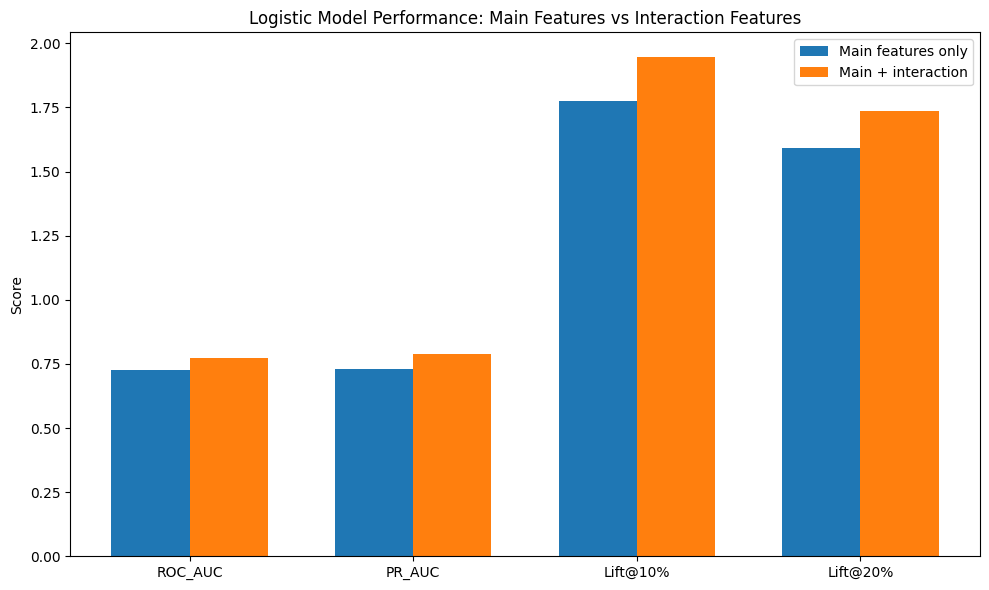

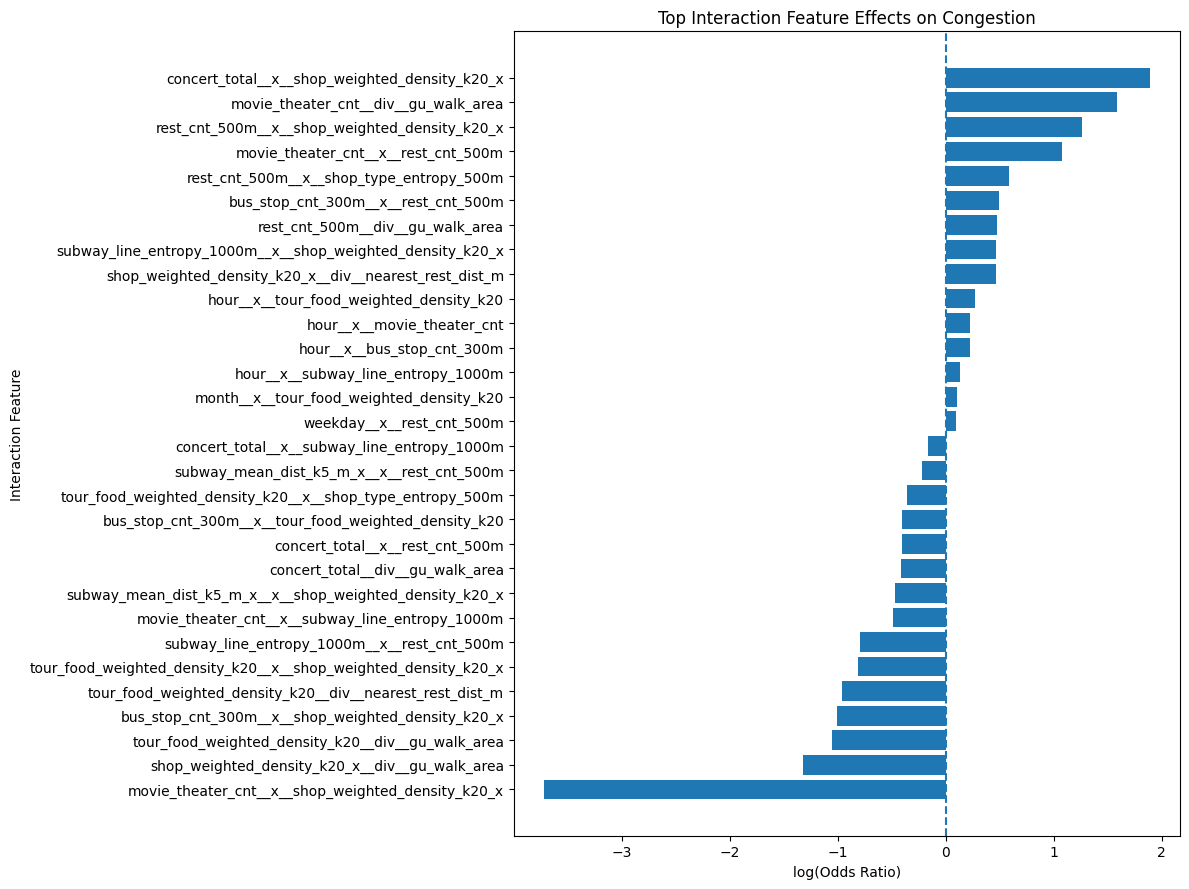

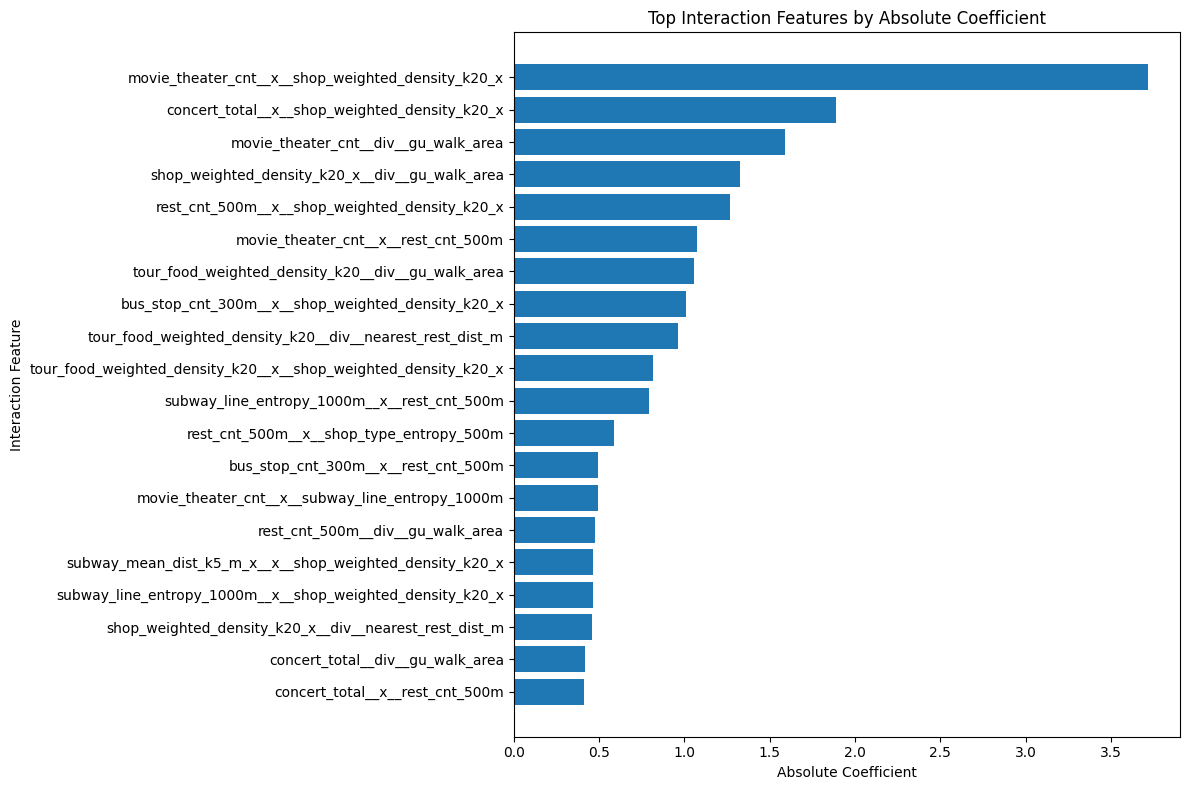

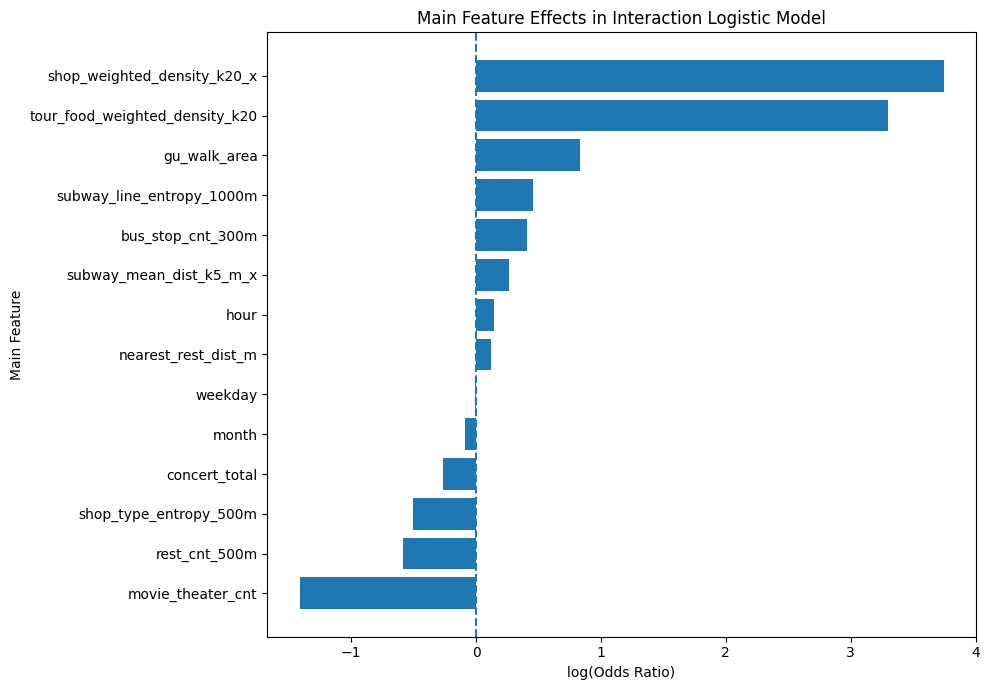


저장 완료:
- logistic_main_vs_interaction_selected_features.csv
- logistic_interaction_improvement_selected_features.csv
- logistic_interaction_coefficients_selected_features.csv
- logistic_interaction_only_effects_selected_features.csv


59631

In [15]:
# =========================================================
# 선택 피처 기반 Logistic Interaction 분석
# - 기본 피처 모델 vs 상호작용 피처 추가 모델 비교
# - interaction feature 효과 확인
# - 숫자 + 시각화 + 저장
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score


# =========================================================
# 1. 선택 피처 지정
# =========================================================

selected_features = [
    "subway_line_entropy_1000m",
    "subway_mean_dist_k5_m_x",
    "rest_cnt_500m",
    "shop_weighted_density_k20_x",
    "movie_theater_cnt",
    "shop_type_entropy_500m",
    "gu_walk_area",
    "concert_total",
    "tour_food_weighted_density_k20",
    "nearest_rest_dist_m",
    "bus_stop_cnt_300m",
    "month",
    "hour",
    "weekday",
]

target_col = "target"

selected_features = [
    c for c in selected_features
    if c in df.columns
]

print("사용 피처 수:", len(selected_features))
print(selected_features)


# =========================================================
# 2. X, y 생성
# =========================================================

X_main = df[selected_features].copy()
y = df[target_col].astype(int).copy()

for col in X_main.columns:
    X_main[col] = pd.to_numeric(X_main[col], errors="coerce").astype("float32")

print("\nX_main shape:", X_main.shape)
print("\nTarget distribution:")
print(y.value_counts(normalize=True))


# =========================================================
# 3. 상호작용 피처 생성 함수
# =========================================================

def safe_divide(a, b, eps=1e-6):
    return a / (np.abs(b) + eps)


# 도메인 기반 interaction 조합
interaction_specs = [
    # 시간 × 교통
    ("hour", "subway_line_entropy_1000m", "mul"),
    ("hour", "subway_mean_dist_k5_m_x", "mul"),
    ("hour", "bus_stop_cnt_300m", "mul"),

    # 시간 × 음식/상권/문화
    ("hour", "rest_cnt_500m", "mul"),
    ("hour", "tour_food_weighted_density_k20", "mul"),
    ("hour", "shop_weighted_density_k20_x", "mul"),
    ("hour", "movie_theater_cnt", "mul"),
    ("hour", "concert_total", "mul"),

    # 요일/월 × 핵심 기능
    ("weekday", "rest_cnt_500m", "mul"),
    ("weekday", "shop_weighted_density_k20_x", "mul"),
    ("month", "rest_cnt_500m", "mul"),
    ("month", "tour_food_weighted_density_k20", "mul"),

    # 교통 × 음식
    ("subway_line_entropy_1000m", "rest_cnt_500m", "mul"),
    ("subway_mean_dist_k5_m_x", "rest_cnt_500m", "mul"),
    ("bus_stop_cnt_300m", "rest_cnt_500m", "mul"),
    ("subway_line_entropy_1000m", "tour_food_weighted_density_k20", "mul"),
    ("bus_stop_cnt_300m", "tour_food_weighted_density_k20", "mul"),

    # 교통 × 상권
    ("subway_line_entropy_1000m", "shop_weighted_density_k20_x", "mul"),
    ("subway_mean_dist_k5_m_x", "shop_weighted_density_k20_x", "mul"),
    ("bus_stop_cnt_300m", "shop_weighted_density_k20_x", "mul"),

    # 음식 × 상권
    ("rest_cnt_500m", "shop_weighted_density_k20_x", "mul"),
    ("tour_food_weighted_density_k20", "shop_weighted_density_k20_x", "mul"),
    ("rest_cnt_500m", "shop_type_entropy_500m", "mul"),
    ("tour_food_weighted_density_k20", "shop_type_entropy_500m", "mul"),

    # 문화 × 교통/상권/음식
    ("movie_theater_cnt", "subway_line_entropy_1000m", "mul"),
    ("movie_theater_cnt", "rest_cnt_500m", "mul"),
    ("movie_theater_cnt", "shop_weighted_density_k20_x", "mul"),
    ("concert_total", "subway_line_entropy_1000m", "mul"),
    ("concert_total", "rest_cnt_500m", "mul"),
    ("concert_total", "shop_weighted_density_k20_x", "mul"),

    # 보행면적 대비 기능 밀도
    ("rest_cnt_500m", "gu_walk_area", "ratio"),
    ("shop_weighted_density_k20_x", "gu_walk_area", "ratio"),
    ("tour_food_weighted_density_k20", "gu_walk_area", "ratio"),
    ("movie_theater_cnt", "gu_walk_area", "ratio"),
    ("concert_total", "gu_walk_area", "ratio"),

    # 거리 보정
    ("rest_cnt_500m", "nearest_rest_dist_m", "ratio"),
    ("tour_food_weighted_density_k20", "nearest_rest_dist_m", "ratio"),
    ("shop_weighted_density_k20_x", "nearest_rest_dist_m", "ratio"),
]


def create_interaction_features(X, specs):
    X_inter = X.copy()
    created_cols = []

    for col1, col2, op in specs:
        if col1 not in X_inter.columns or col2 not in X_inter.columns:
            continue

        if op == "mul":
            new_col = f"{col1}__x__{col2}"
            X_inter[new_col] = (
                X_inter[col1].astype("float32") * X_inter[col2].astype("float32")
            ).astype("float32")

        elif op == "ratio":
            new_col = f"{col1}__div__{col2}"
            X_inter[new_col] = safe_divide(
                X_inter[col1].astype("float32"),
                X_inter[col2].astype("float32")
            ).astype("float32")

        else:
            continue

        created_cols.append(new_col)

    return X_inter, created_cols


X_interaction, interaction_cols = create_interaction_features(
    X_main,
    interaction_specs
)

print("\n생성된 interaction feature 수:", len(interaction_cols))
for col in interaction_cols:
    print("-", col)

print("\nX_main shape:", X_main.shape)
print("X_interaction shape:", X_interaction.shape)


# =========================================================
# 4. 평가 함수
# =========================================================

def calculate_lift(y_true, y_proba, top_ratio):
    temp = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_proba": np.asarray(y_proba)
    })

    temp = temp.sort_values("y_proba", ascending=False)

    top_n = max(1, int(len(temp) * top_ratio))

    base_rate = temp["y_true"].mean()
    top_rate = temp.iloc[:top_n]["y_true"].mean()

    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return lift, top_rate, base_rate


def evaluate_model(model_name, y_test, y_pred, y_proba):
    lift_5, top_rate_5, base_rate = calculate_lift(y_test, y_proba, 0.05)
    lift_10, top_rate_10, _ = calculate_lift(y_test, y_proba, 0.10)
    lift_20, top_rate_20, _ = calculate_lift(y_test, y_proba, 0.20)

    return {
        "model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "PR_AUC": average_precision_score(y_test, y_proba),
        "Lift@5%": lift_5,
        "Lift@10%": lift_10,
        "Lift@20%": lift_20,
        "Top5%_positive_rate": top_rate_5,
        "Top10%_positive_rate": top_rate_10,
        "Top20%_positive_rate": top_rate_20,
        "Base_positive_rate": base_rate,
    }


def train_logistic(X, y, model_name):
    print(f"\n===== {model_name} =====")
    print("Input shape:", X.shape)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(
            solver="lbfgs",
            penalty="l2",
            C=1.0,
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        ))
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    result = evaluate_model(
        model_name,
        y_test,
        y_pred,
        y_proba
    )

    return result, pipe


# =========================================================
# 5. 기본 모델 vs interaction 모델 학습
# =========================================================

results = []

result_main, pipe_main = train_logistic(
    X_main,
    y,
    "Logistic_main_features_only"
)
results.append(result_main)

result_inter, pipe_inter = train_logistic(
    X_interaction,
    y,
    "Logistic_main_plus_interaction"
)
results.append(result_inter)


# =========================================================
# 6. 성능 비교표
# =========================================================

comparison_df = pd.DataFrame(results)

metric_cols = [
    "Accuracy",
    "F1",
    "ROC_AUC",
    "PR_AUC",
    "Lift@5%",
    "Lift@10%",
    "Lift@20%",
    "Top5%_positive_rate",
    "Top10%_positive_rate",
    "Top20%_positive_rate",
    "Base_positive_rate"
]

comparison_df[metric_cols] = comparison_df[metric_cols].round(4)

print("\n===== 기본 피처 vs 상호작용 피처 성능 비교 =====")
print(comparison_df)


# =========================================================
# 7. 개선폭 계산
# =========================================================

main_row = comparison_df[
    comparison_df["model"] == "Logistic_main_features_only"
].iloc[0]

inter_row = comparison_df[
    comparison_df["model"] == "Logistic_main_plus_interaction"
].iloc[0]

improvement_df = pd.DataFrame([{
    "comparison": "main_plus_interaction - main_features_only",
    "Accuracy_diff": inter_row["Accuracy"] - main_row["Accuracy"],
    "F1_diff": inter_row["F1"] - main_row["F1"],
    "ROC_AUC_diff": inter_row["ROC_AUC"] - main_row["ROC_AUC"],
    "PR_AUC_diff": inter_row["PR_AUC"] - main_row["PR_AUC"],
    "Lift@5%_diff": inter_row["Lift@5%"] - main_row["Lift@5%"],
    "Lift@10%_diff": inter_row["Lift@10%"] - main_row["Lift@10%"],
    "Lift@20%_diff": inter_row["Lift@20%"] - main_row["Lift@20%"],
}]).round(4)

print("\n===== 개선폭 =====")
print(improvement_df)


# =========================================================
# 8. interaction 포함 모델의 coef / OR 정리
# =========================================================

feature_names = X_interaction.columns.tolist()
coef = pipe_inter.named_steps["logit"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "OR": np.exp(coef),
})

coef_df["log_OR"] = np.log(coef_df["OR"])
coef_df["abs_coef"] = np.abs(coef_df["coef"])

coef_df["feature_type"] = np.where(
    coef_df["feature"].isin(interaction_cols),
    "interaction",
    "main"
)

coef_df = coef_df.sort_values(
    by="abs_coef",
    ascending=False
).reset_index(drop=True)

print("\n===== 전체 feature 계수 Top 30 =====")
print(coef_df.head(30))

print("\n===== interaction feature 계수 Top 20 =====")
print(
    coef_df[
        coef_df["feature_type"] == "interaction"
    ].head(20)
)


# =========================================================
# 9. 효과가 큰 interaction feature 정리
# =========================================================

interaction_effect_df = coef_df[
    coef_df["feature_type"] == "interaction"
].copy()

top_positive_interaction = interaction_effect_df.sort_values(
    by="log_OR",
    ascending=False
).head(15)

top_negative_interaction = interaction_effect_df.sort_values(
    by="log_OR",
    ascending=True
).head(15)

top_abs_interaction = interaction_effect_df.sort_values(
    by="abs_coef",
    ascending=False
).head(20)

print("\n===== 혼잡 증가 방향 interaction Top 15 =====")
print(top_positive_interaction[["feature", "coef", "OR", "log_OR"]])

print("\n===== 혼잡 감소 방향 interaction Top 15 =====")
print(top_negative_interaction[["feature", "coef", "OR", "log_OR"]])

print("\n===== 절대 영향력 기준 interaction Top 20 =====")
print(top_abs_interaction[["feature", "coef", "OR", "log_OR", "abs_coef"]])


# =========================================================
# 10. 시각화 1: 모델 성능 비교
# =========================================================

plot_metrics = ["ROC_AUC", "PR_AUC", "Lift@10%", "Lift@20%"]

performance_plot_df = comparison_df.set_index("model")[plot_metrics].T

plt.figure(figsize=(10, 6))

x = np.arange(len(plot_metrics))
width = 0.35

plt.bar(
    x - width / 2,
    performance_plot_df["Logistic_main_features_only"],
    width,
    label="Main features only"
)

plt.bar(
    x + width / 2,
    performance_plot_df["Logistic_main_plus_interaction"],
    width,
    label="Main + interaction"
)

plt.xticks(x, plot_metrics)
plt.ylabel("Score")
plt.title("Logistic Model Performance: Main Features vs Interaction Features")
plt.legend()
plt.tight_layout()
plt.show()


# =========================================================
# 11. 시각화 2: interaction log(OR)
# =========================================================

plot_interaction = pd.concat([
    top_negative_interaction,
    top_positive_interaction
]).sort_values("log_OR")

plt.figure(figsize=(12, 9))

plt.barh(
    plot_interaction["feature"],
    plot_interaction["log_OR"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("log(Odds Ratio)")
plt.ylabel("Interaction Feature")
plt.title("Top Interaction Feature Effects on Congestion")

plt.tight_layout()
plt.show()


# =========================================================
# 12. 시각화 3: 절대 영향력 Top interaction
# =========================================================

plot_abs = top_abs_interaction.sort_values("abs_coef")

plt.figure(figsize=(12, 8))

plt.barh(
    plot_abs["feature"],
    plot_abs["abs_coef"]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Interaction Feature")
plt.title("Top Interaction Features by Absolute Coefficient")

plt.tight_layout()
plt.show()


# =========================================================
# 13. 시각화 4: main feature log(OR)
# =========================================================

main_effect_df = coef_df[
    coef_df["feature_type"] == "main"
].copy()

main_effect_df = main_effect_df.sort_values("log_OR")

plt.figure(figsize=(10, 7))

plt.barh(
    main_effect_df["feature"],
    main_effect_df["log_OR"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("log(Odds Ratio)")
plt.ylabel("Main Feature")
plt.title("Main Feature Effects in Interaction Logistic Model")

plt.tight_layout()
plt.show()


# =========================================================
# 14. 저장
# =========================================================

comparison_df.to_csv(
    "logistic_main_vs_interaction_selected_features.csv",
    index=False,
    encoding="utf-8-sig"
)

improvement_df.to_csv(
    "logistic_interaction_improvement_selected_features.csv",
    index=False,
    encoding="utf-8-sig"
)

coef_df.to_csv(
    "logistic_interaction_coefficients_selected_features.csv",
    index=False,
    encoding="utf-8-sig"
)

interaction_effect_df.to_csv(
    "logistic_interaction_only_effects_selected_features.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n저장 완료:")
print("- logistic_main_vs_interaction_selected_features.csv")
print("- logistic_interaction_improvement_selected_features.csv")
print("- logistic_interaction_coefficients_selected_features.csv")
print("- logistic_interaction_only_effects_selected_features.csv")

gc.collect()